In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("tnea_cutoffs.csv")
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (3457, 13)
   college_code                                       college_name district  \
0             1  University Departments of Anna University  Che...  CHENNAI   
1             1  University Departments of Anna University  Che...  CHENNAI   
2             1  University Departments of Anna University  Che...  CHENNAI   
3             1  University Departments of Anna University  Che...  CHENNAI   
4             1  University Departments of Anna University  Che...  CHENNAI   

  college_type branch_code                                branch_name     oc  \
0    CEG DEPTS          BY              BIO MEDICAL ENGINEERING  (SS)  195.5   
1    CEG DEPTS          CE                         CIVIL  ENGINEERING  195.5   
2    CEG DEPTS          CM      COMPUTER SCIENCE AND ENGINEERING (SS)  199.5   
3    CEG DEPTS          CS           COMPUTER SCIENCE AND ENGINEERING  200.0   
4    CEG DEPTS          EC  ELECTRONICS AND COMMUNICATION ENGINEERING  199.5   

      bc    bcm   

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3457 entries, 0 to 3456
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   college_code  3457 non-null   int64  
 1   college_name  3457 non-null   object 
 2   district      3457 non-null   object 
 3   college_type  3457 non-null   object 
 4   branch_code   3457 non-null   object 
 5   branch_name   3457 non-null   object 
 6   oc            3302 non-null   float64
 7   bc            2644 non-null   float64
 8   bcm           2009 non-null   float64
 9   mbc           2628 non-null   float64
 10  sc            2495 non-null   float64
 11  sca           1334 non-null   float64
 12  st            498 non-null    float64
dtypes: float64(7), int64(1), object(5)
memory usage: 351.2+ KB
None


In [4]:
print(df.describe())

       college_code           oc           bc          bcm          mbc  \
count   3457.000000  3302.000000  2644.000000  2009.000000  2628.000000   
mean    2909.976280   141.149651   133.244368   143.943380   133.038304   
std     1496.360936    30.114735    33.410874    29.227776    31.315408   
min        1.000000    79.500000    78.145000    80.000000    79.000000   
25%     1437.000000   118.500000   103.500000   120.500000   106.500000   
50%     2705.000000   142.000000   130.500000   145.500000   130.500000   
75%     3845.000000   165.500000   162.500000   168.000000   158.000000   
max     5990.000000   200.000000   200.000000   199.500000   200.000000   

                sc          sca          st  
count  2495.000000  1334.000000  498.000000  
mean    120.345830   128.077955  136.671687  
std      26.931096    25.279776   26.892478  
min      78.000000    77.500000   81.000000  
25%     100.500000   109.500000  115.500000  
50%     114.000000   124.000000  134.250000  
75

In [5]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [6]:
missing = df.isnull().sum()

print(missing)

college_code       0
college_name       0
district           0
college_type       0
branch_code        0
branch_name        0
oc               155
bc               813
bcm             1448
mbc              829
sc               962
sca             2123
st              2959
dtype: int64


In [7]:
df.columns = df.columns.str.strip().str.lower()

df.head()

,college_code,college_name,district,college_type,branch_code,branch_name,oc,bc,bcm,mbc,sc,sca,st
0,1,University Departments of Anna University Che...,CHENNAI,CEG DEPTS,BY,BIO MEDICAL ENGINEERING (SS),195.5,193.0,190.0,193.0,189.5,179.000000,185.5
1,1,University Departments of Anna University Che...,CHENNAI,CEG DEPTS,CE,CIVIL ENGINEERING,195.5,193.5,195.0,194.5,193.0,182.500000,182.5
2,1,University Departments of Anna University Che...,CHENNAI,CEG DEPTS,CM,COMPUTER SCIENCE AND ENGINEERING (SS),199.5,199.0,199.5,199.0,196.5,191.000000,196.0
3,1,University Departments of Anna University Che...,CHENNAI,CEG DEPTS,CS,COMPUTER SCIENCE AND ENGINEERING,200.0,200.0,199.5,200.0,198.5,198.666667,197.0
4,1,University Departments of Anna University Che...,CHENNAI,CEG DEPTS,EC,ELECTRONICS AND COMMUNICATION ENGINEERING,199.5,199.5,198.5,199.0,197.5,192.500000,NaN


In [8]:
text_columns = [
    "college_name",
    "district",
    "college_type",
    "branch_code",
    "branch_name"
]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

In [9]:
caste_columns = [
    "oc",
    "bc",
    "bcm",
    "mbc",
    "sc",
    "sca",
    "st"
]

for col in caste_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [10]:
print(df[caste_columns].dtypes)

oc     float64
bc     float64
bcm    float64
mbc    float64
sc     float64
sca    float64
st     float64
dtype: object


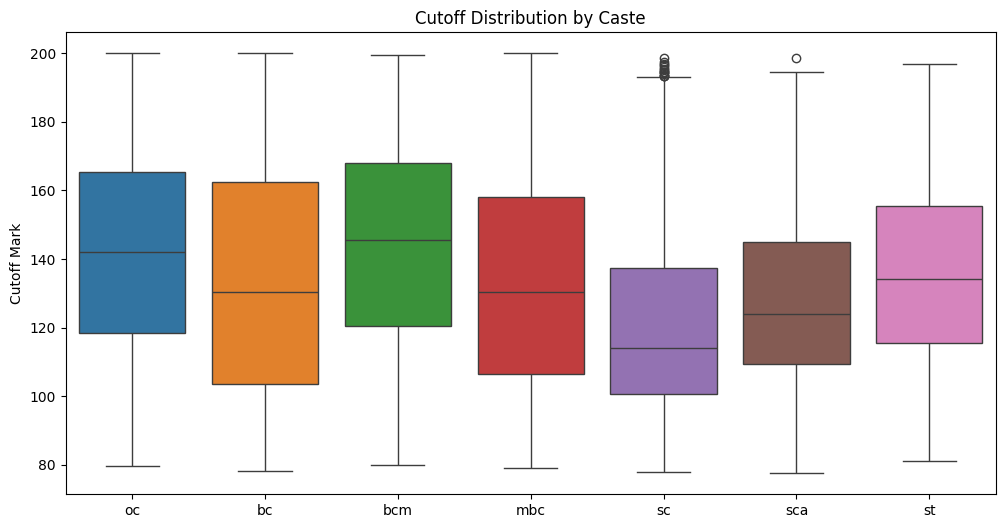

In [11]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[caste_columns])

plt.title("Cutoff Distribution by Caste")
plt.ylabel("Cutoff Mark")

plt.show()

In [12]:
df[caste_columns].describe()

,oc,bc,bcm,mbc,sc,sca,st
count,3302.000000,2644.000000,2009.000000,2628.000000,2495.000000,1334.000000,498.000000
mean,141.149651,133.244368,143.943380,133.038304,120.345830,128.077955,136.671687
std,30.114735,33.410874,29.227776,31.315408,26.931096,25.279776,26.892478
min,79.500000,78.145000,80.000000,79.000000,78.000000,77.500000,81.000000
25%,118.500000,103.500000,120.500000,106.500000,100.500000,109.500000,115.500000
50%,142.000000,130.500000,145.500000,130.500000,114.000000,124.000000,134.250000
75%,165.500000,162.500000,168.000000,158.000000,137.500000,144.875000,155.500000
max,200.000000,200.000000,199.500000,200.000000,198.500000,198.666667,197.000000


In [13]:
branch_count = df["branch_name"].value_counts()

print(branch_count.head(20))

branch_name
COMPUTER SCIENCE AND ENGINEERING                              413
ELECTRONICS AND COMMUNICATION ENGINEERING                     403
MECHANICAL ENGINEERING                                        379
ELECTRICAL AND ELECTRONICS ENGINEERING                        353
Artificial Intelligence and Data Science                      335
INFORMATION TECHNOLOGY                                        297
CIVIL  ENGINEERING                                            266
Computer Science and Engineering (Cyber Security)             138
COMPUTER SCIENCE AND ENGINEERING (AI AND MACHINE LEARNING)    130
BIO MEDICAL ENGINEERING                                       105
COMPUTER SCIENCE AND BUSSINESS SYSTEM                          70
AGRICULTURAL ENGINEERING                                       60
BIO TECHNOLOGY                                                 42
AERONAUTICAL ENGINEERING                                       37
Mechatronics Engineering                                       3

In [14]:
district_count = df["district"].value_counts()

print(district_count)

district
COIMBATORE         511
CHENGALPET         275
KANCHEEPURAM       250
THIRUVALLUR        238
KANYAKUMARI        197
NAMAKKAL           196
TIRUCHIRAPALLI     181
SALEM              146
ERODE              130
DINDIGUL            99
TIRUNELVELI         94
MADURAI             87
VIRUDHUNAGAR        77
PUDUKKOTTAI         74
THANJAVUR           70
VILUPPURAM          68
TUTICORIN           67
CHENNAI             62
CUDDALORE           58
THIRUVANNAMALAI     57
SIVAGANGAI          56
KARUR               42
KRISHNAGIRI         40
DHARMAPURI          38
TIRUPPUR            36
RANIPET             34
VELLORE             31
NAGAPATTINAM        31
RAMANATHAPURAM      30
THENI               28
TENKASI             27
KALLAKURICHI        26
PERAMBALUR          25
ARIYALUR            21
THIRUPATHUR         19
THIRUVARUR          16
MAYILADUTHURAI       8
THE NILGIRIS         7
TRICHIRAPPALLI       5
Name: count, dtype: int64


In [15]:
caste_mapping = {
    "OC": "oc",
    "BC": "bc",
    "BCM": "bcm",
    "MBC": "mbc",
    "SC": "sc",
    "SCA": "sca",
    "ST": "st"
}

In [16]:
def recommend_colleges(mark, caste):

    caste = caste.upper().strip()

    if caste not in caste_mapping:
        print("Invalid caste.")
        print("Available:", list(caste_mapping.keys()))
        return None

    cutoff_column = caste_mapping[caste]

    result = df[
        df[cutoff_column].notna() &
        (df[cutoff_column] <= mark)
    ].copy()

    result["cutoff"] = result[cutoff_column]

    result["difference"] = mark - result["cutoff"]

    result = result.sort_values(
        by="cutoff",
        ascending=False
    )

    return result[
        [
            "college_code",
            "college_name",
            "district",
            "college_type",
            "branch_code",
            "branch_name",
            "cutoff",
            "difference"
        ]
    ]

In [17]:
student_mark = 195
student_caste = "BC"

recommendations = recommend_colleges(
    student_mark,
    student_caste
)

recommendations.head(20)

,college_code,college_name,district,college_type,branch_code,branch_name,cutoff,difference
48,2005,Government College of Technology (Autonomous) ...,COIMBATORE,GOVERNMENT ENGG COLLEGES,AM,COMPUTER SCIENCE AND ENGINEERING (AI AND MACHI...,195.0,0.0
147,2007,Coimbatore Institute of Technology (Autonomous...,COIMBATORE,GOVERNMENT AIDED COLLEGES,EE,ELECTRICAL AND ELECTRONICS ENGINEERING,195.0,0.0
12,1,University Departments of Anna University Che...,CHENNAI,CEG DEPTS,ME,MECHANICAL ENGINEERING,195.0,0.0
30,4,University Departments of Anna University Che...,CHENGALPET,CEG DEPTS,AE,AERONAUTICAL ENGINEERING,194.5,0.5
161,5008,Thiagarajar College of Engineering (Autonomous...,MADURAI,GOVERNMENT AIDED COLLEGES,EM,ELECTRONICS AND COMMUNICATION ENGINEERING (SS),194.5,0.5
129,2006,PSG College of Technology (Autonomous) Peelam...,COIMBATORE,GOVERNMENT AIDED COLLEGES,ME,MECHANICAL ENGINEERING,194.5,0.5
1423,2377,PSG Institute of Technology and Applied Resear...,COIMBATORE,SELF FINANCING COLLEGES TIER 1,EV,Electronics Engineering (VLSI Design and Techn...,194.5,0.5
1952,2712,"Kumaraguru College of Technology (Autonomous),...",COIMBATORE,SELF FINANCING COLLEGES TIER 1,CS,COMPUTER SCIENCE AND ENGINEERING,194.5,0.5
136,2006,PSG College of Technology (Autonomous) Peelam...,COIMBATORE,GOVERNMENT AIDED COLLEGES,RA,ROBOTICS AND AUTOMATION (SS),194.5,0.5
1953,2712,"Kumaraguru College of Technology (Autonomous),...",COIMBATORE,SELF FINANCING COLLEGES TIER 1,EC,ELECTRONICS AND COMMUNICATION ENGINEERING,194.0,1.0


In [18]:
def categorize_colleges(mark, caste):

    result = recommend_colleges(mark, caste)

    if result is None or result.empty:
        return None

    result["category"] = np.where(
        result["difference"] >= 5,
        "Safe",
        np.where(
            result["difference"] >= 2,
            "Moderate",
            "Reach"
        )
    )

    return result

In [19]:
result = categorize_colleges(195, "BC")

result.head(20)

,college_code,college_name,district,college_type,branch_code,branch_name,cutoff,difference,category
48,2005,Government College of Technology (Autonomous) ...,COIMBATORE,GOVERNMENT ENGG COLLEGES,AM,COMPUTER SCIENCE AND ENGINEERING (AI AND MACHI...,195.0,0.0,Reach
147,2007,Coimbatore Institute of Technology (Autonomous...,COIMBATORE,GOVERNMENT AIDED COLLEGES,EE,ELECTRICAL AND ELECTRONICS ENGINEERING,195.0,0.0,Reach
12,1,University Departments of Anna University Che...,CHENNAI,CEG DEPTS,ME,MECHANICAL ENGINEERING,195.0,0.0,Reach
30,4,University Departments of Anna University Che...,CHENGALPET,CEG DEPTS,AE,AERONAUTICAL ENGINEERING,194.5,0.5,Reach
161,5008,Thiagarajar College of Engineering (Autonomous...,MADURAI,GOVERNMENT AIDED COLLEGES,EM,ELECTRONICS AND COMMUNICATION ENGINEERING (SS),194.5,0.5,Reach
129,2006,PSG College of Technology (Autonomous) Peelam...,COIMBATORE,GOVERNMENT AIDED COLLEGES,ME,MECHANICAL ENGINEERING,194.5,0.5,Reach
1423,2377,PSG Institute of Technology and Applied Resear...,COIMBATORE,SELF FINANCING COLLEGES TIER 1,EV,Electronics Engineering (VLSI Design and Techn...,194.5,0.5,Reach
1952,2712,"Kumaraguru College of Technology (Autonomous),...",COIMBATORE,SELF FINANCING COLLEGES TIER 1,CS,COMPUTER SCIENCE AND ENGINEERING,194.5,0.5,Reach
136,2006,PSG College of Technology (Autonomous) Peelam...,COIMBATORE,GOVERNMENT AIDED COLLEGES,RA,ROBOTICS AND AUTOMATION (SS),194.5,0.5,Reach
1953,2712,"Kumaraguru College of Technology (Autonomous),...",COIMBATORE,SELF FINANCING COLLEGES TIER 1,EC,ELECTRONICS AND COMMUNICATION ENGINEERING,194.0,1.0,Reach


In [20]:
safe = result[result["category"] == "Safe"]

safe.head(20)

,college_code,college_name,district,college_type,branch_code,branch_name,cutoff,difference,category
2143,2739,Sri Eshwar College of Engineering (Autonomous)...,COIMBATORE,SELF FINANCING COLLEGES TIER 3,EC,ELECTRONICS AND COMMUNICATION ENGINEERING,190.000000,5.000000,Safe
20,2,University Departments of Anna University Che...,CHENNAI,CEG DEPTS,CL,CHEMICAL ENGINEERING (SS),190.000000,5.000000,Safe
2292,2764,KPR Institute of Engineering and Technology (A...,COIMBATORE,SELF FINANCING COLLEGES TIER 3,CS,COMPUTER SCIENCE AND ENGINEERING,190.000000,5.000000,Safe
777,1315,Sri Sivasubramaniya Nadar College of Engineeri...,CHENGALPET,SELF FINANCING COLLEGES TIER 1,CH,CHEMICAL ENGINEERING,190.000000,5.000000,Safe
775,1315,Sri Sivasubramaniya Nadar College of Engineeri...,CHENGALPET,SELF FINANCING COLLEGES TIER 1,BM,BIO MEDICAL ENGINEERING,190.000000,5.000000,Safe
167,5008,Thiagarajar College of Engineering (Autonomous...,MADURAI,GOVERNMENT AIDED COLLEGES,MG,MECHATRONICS (SS),190.000000,5.000000,Safe
165,5008,Thiagarajar College of Engineering (Autonomous...,MADURAI,GOVERNMENT AIDED COLLEGES,ME,MECHANICAL ENGINEERING,189.500000,5.500000,Safe
1926,2710,"Karpagam College of Engineering (Autonomous), ...",COIMBATORE,SELF FINANCING COLLEGES TIER 1,CS,COMPUTER SCIENCE AND ENGINEERING,189.500000,5.500000,Safe
1424,2377,PSG Institute of Technology and Applied Resear...,COIMBATORE,SELF FINANCING COLLEGES TIER 1,IC,INSTRUMENTATION AND CONTROL ENGINEERING,189.500000,5.500000,Safe
2008,2718,Sri Krishna College of Engineering and Technol...,COIMBATORE,SELF FINANCING COLLEGES TIER 1,CS,COMPUTER SCIENCE AND ENGINEERING,189.500000,5.500000,Safe


In [21]:
best_colleges = result.sort_values(
    by="cutoff",
    ascending=False
)

best_colleges.head(20)

,college_code,college_name,district,college_type,branch_code,branch_name,cutoff,difference,category
48,2005,Government College of Technology (Autonomous) ...,COIMBATORE,GOVERNMENT ENGG COLLEGES,AM,COMPUTER SCIENCE AND ENGINEERING (AI AND MACHI...,195.0,0.0,Reach
147,2007,Coimbatore Institute of Technology (Autonomous...,COIMBATORE,GOVERNMENT AIDED COLLEGES,EE,ELECTRICAL AND ELECTRONICS ENGINEERING,195.0,0.0,Reach
12,1,University Departments of Anna University Che...,CHENNAI,CEG DEPTS,ME,MECHANICAL ENGINEERING,195.0,0.0,Reach
30,4,University Departments of Anna University Che...,CHENGALPET,CEG DEPTS,AE,AERONAUTICAL ENGINEERING,194.5,0.5,Reach
161,5008,Thiagarajar College of Engineering (Autonomous...,MADURAI,GOVERNMENT AIDED COLLEGES,EM,ELECTRONICS AND COMMUNICATION ENGINEERING (SS),194.5,0.5,Reach
129,2006,PSG College of Technology (Autonomous) Peelam...,COIMBATORE,GOVERNMENT AIDED COLLEGES,ME,MECHANICAL ENGINEERING,194.5,0.5,Reach
1952,2712,"Kumaraguru College of Technology (Autonomous),...",COIMBATORE,SELF FINANCING COLLEGES TIER 1,CS,COMPUTER SCIENCE AND ENGINEERING,194.5,0.5,Reach
1423,2377,PSG Institute of Technology and Applied Resear...,COIMBATORE,SELF FINANCING COLLEGES TIER 1,EV,Electronics Engineering (VLSI Design and Techn...,194.5,0.5,Reach
136,2006,PSG College of Technology (Autonomous) Peelam...,COIMBATORE,GOVERNMENT AIDED COLLEGES,RA,ROBOTICS AND AUTOMATION (SS),194.5,0.5,Reach
154,5008,Thiagarajar College of Engineering (Autonomous...,MADURAI,GOVERNMENT AIDED COLLEGES,CG,Computer Science and Engineering (Artificial I...,194.0,1.0,Reach


In [22]:
def recommend_by_district(mark, caste, district):

    result = recommend_colleges(mark, caste)

    if result is None:
        return None

    result = result[
        result["district"].str.upper() == district.upper()
    ]

    return result

In [23]:
recommend_by_district(
    195,
    "BC",
    "CHENNAI"
).head(20)

,college_code,college_name,district,college_type,branch_code,branch_name,cutoff,difference
12,1,University Departments of Anna University Che...,CHENNAI,CEG DEPTS,ME,MECHANICAL ENGINEERING,195.000000,0.000000
1,1,University Departments of Anna University Che...,CHENNAI,CEG DEPTS,CE,CIVIL ENGINEERING,193.500000,1.500000
0,1,University Departments of Anna University Che...,CHENNAI,CEG DEPTS,BY,BIO MEDICAL ENGINEERING (SS),193.000000,2.000000
19,2,University Departments of Anna University Che...,CHENNAI,CEG DEPTS,CH,CHEMICAL ENGINEERING,191.000000,4.000000
20,2,University Departments of Anna University Che...,CHENNAI,CEG DEPTS,CL,CHEMICAL ENGINEERING (SS),190.000000,5.000000
8,1,University Departments of Anna University Che...,CHENNAI,CEG DEPTS,GI,GEO INFORMATICS,189.500000,5.500000
11,1,University Departments of Anna University Che...,CHENNAI,CEG DEPTS,MA,MATERIAL SCIENCE AND ENGINEERING (SS),189.500000,5.500000
9,1,University Departments of Anna University Che...,CHENNAI,CEG DEPTS,IE,INDUSTRIAL ENGINEERING,189.000000,6.000000
23,2,University Departments of Anna University Che...,CHENNAI,CEG DEPTS,IB,INDUSTRIAL BIO TECHNOLOGY,188.666667,6.333333
1131,1450,Loyola-ICAM College of Engineering and Technol...,CHENNAI,SELF FINANCING COLLEGES TIER 2,CS,COMPUTER SCIENCE AND ENGINEERING,188.500000,6.500000


In [24]:
def recommend_by_branch(mark, caste, branch_keyword):

    result = recommend_colleges(mark, caste)

    if result is None:
        return None

    result = result[
        result["branch_name"].str.contains(
            branch_keyword,
            case=False,
            na=False
        )
    ]

    return result

In [25]:
recommend_by_branch(
    195,
    "BC",
    "COMPUTER SCIENCE"
)

,college_code,college_name,district,college_type,branch_code,branch_name,cutoff,difference
48,2005,Government College of Technology (Autonomous) ...,COIMBATORE,GOVERNMENT ENGG COLLEGES,AM,COMPUTER SCIENCE AND ENGINEERING (AI AND MACHI...,195.000,0.000
1952,2712,"Kumaraguru College of Technology (Autonomous),...",COIMBATORE,SELF FINANCING COLLEGES TIER 1,CS,COMPUTER SCIENCE AND ENGINEERING,194.500,0.500
870,1399,Chennai Institute of Technology (Autonomous) P...,KANCHEEPURAM,SELF FINANCING COLLEGES TIER 1,CS,COMPUTER SCIENCE AND ENGINEERING,194.000,1.000
154,5008,Thiagarajar College of Engineering (Autonomous...,MADURAI,GOVERNMENT AIDED COLLEGES,CG,Computer Science and Engineering (Artificial I...,194.000,1.000
71,2615,Government College of Engineering (Autonomous)...,SALEM,GOVERNMENT ENGG COLLEGES,CS,COMPUTER SCIENCE AND ENGINEERING,194.000,1.000
...,...,...,...,...,...,...,...,...
607,1222,"P.B. College of Engineering, Chennai-Bangalore...",KANCHEEPURAM,SELF FINANCING COLLEGES TIER 3,CS,COMPUTER SCIENCE AND ENGINEERING,81.000,114.000
3080,4975,"Dr G.U. Pope College of Engineering, Pope Naga...",TUTICORIN,SELF FINANCING COLLEGES TIER 3,CS,COMPUTER SCIENCE AND ENGINEERING,80.500,114.500
2957,4953,"Cape Institute of Technology, Rajakrishnapuram...",TIRUNELVELI,SELF FINANCING COLLEGES TIER 3,CS,COMPUTER SCIENCE AND ENGINEERING,80.000,115.000
2647,3843,"MRK Institute of Technology, Nattarmangalam Po...",CUDDALORE,SELF FINANCING COLLEGES TIER 3,CS,COMPUTER SCIENCE AND ENGINEERING,80.000,115.000


In [26]:
def student_college_recommendation(
    mark,
    caste,
    district=None,
    branch=None
):

    caste = caste.upper().strip()

    if caste not in caste_mapping:
        raise ValueError(
            f"Invalid caste. Choose from {list(caste_mapping.keys())}"
        )

    cutoff_column = caste_mapping[caste]

    result = df[
        df[cutoff_column].notna() &
        (df[cutoff_column] <= mark)
    ].copy()

    result["cutoff"] = result[cutoff_column]

    result["difference"] = (
        mark - result["cutoff"]
    )

    if district:
        result = result[
            result["district"].str.contains(
                district,
                case=False,
                na=False
            )
        ]

    if branch:
        result = result[
            result["branch_name"].str.contains(
                branch,
                case=False,
                na=False
            )
        ]

    result["category"] = np.where(
        result["difference"] >= 5,
        "Safe",
        np.where(
            result["difference"] >= 2,
            "Moderate",
            "Reach"
        )
    )

    result = result.sort_values(
        by="cutoff",
        ascending=False
    )

    return result[
        [
            "college_code",
            "college_name",
            "district",
            "college_type",
            "branch_code",
            "branch_name",
            "cutoff",
            "difference",
            "category"
        ]
    ]

In [27]:
result = student_college_recommendation(
    mark=195,
    caste="BC"
)

print("Total Available Colleges/Branches:", len(result))

result.head(20)

Total Available Colleges/Branches: 2601


,college_code,college_name,district,college_type,branch_code,branch_name,cutoff,difference,category
48,2005,Government College of Technology (Autonomous) ...,COIMBATORE,GOVERNMENT ENGG COLLEGES,AM,COMPUTER SCIENCE AND ENGINEERING (AI AND MACHI...,195.0,0.0,Reach
147,2007,Coimbatore Institute of Technology (Autonomous...,COIMBATORE,GOVERNMENT AIDED COLLEGES,EE,ELECTRICAL AND ELECTRONICS ENGINEERING,195.0,0.0,Reach
12,1,University Departments of Anna University Che...,CHENNAI,CEG DEPTS,ME,MECHANICAL ENGINEERING,195.0,0.0,Reach
30,4,University Departments of Anna University Che...,CHENGALPET,CEG DEPTS,AE,AERONAUTICAL ENGINEERING,194.5,0.5,Reach
161,5008,Thiagarajar College of Engineering (Autonomous...,MADURAI,GOVERNMENT AIDED COLLEGES,EM,ELECTRONICS AND COMMUNICATION ENGINEERING (SS),194.5,0.5,Reach
129,2006,PSG College of Technology (Autonomous) Peelam...,COIMBATORE,GOVERNMENT AIDED COLLEGES,ME,MECHANICAL ENGINEERING,194.5,0.5,Reach
1423,2377,PSG Institute of Technology and Applied Resear...,COIMBATORE,SELF FINANCING COLLEGES TIER 1,EV,Electronics Engineering (VLSI Design and Techn...,194.5,0.5,Reach
1952,2712,"Kumaraguru College of Technology (Autonomous),...",COIMBATORE,SELF FINANCING COLLEGES TIER 1,CS,COMPUTER SCIENCE AND ENGINEERING,194.5,0.5,Reach
136,2006,PSG College of Technology (Autonomous) Peelam...,COIMBATORE,GOVERNMENT AIDED COLLEGES,RA,ROBOTICS AND AUTOMATION (SS),194.5,0.5,Reach
1953,2712,"Kumaraguru College of Technology (Autonomous),...",COIMBATORE,SELF FINANCING COLLEGES TIER 1,EC,ELECTRONICS AND COMMUNICATION ENGINEERING,194.0,1.0,Reach


In [28]:
mark = float(input("Enter your cutoff mark: "))

caste = input(
    "Enter your caste (OC/BC/BCM/MBC/SC/SCA/ST): "
)

result = student_college_recommendation(
    mark,
    caste
)

print("\nAvailable Colleges:")
display(result.head(20))


Available Colleges:


,college_code,college_name,district,college_type,branch_code,branch_name,cutoff,difference,category
60,2369,Government College of Engineering Chettikkara...,DHARMAPURI,GOVERNMENT ENGG COLLEGES,EC,ELECTRONICS AND COMMUNICATION ENGINEERING,165.0,0.0,Reach
3319,5904,"K.L.N.College of Engineering (Autonomous), Mad...",SIVAGANGAI,SELF FINANCING COLLEGES TIER 3,CS,COMPUTER SCIENCE AND ENGINEERING,165.0,0.0,Reach
1373,2349,"Dhaanish Ahmed Institute of Technology, Pitcha...",COIMBATORE,SELF FINANCING COLLEGES TIER 3,IT,INFORMATION TECHNOLOGY,165.0,0.0,Reach
2085,2729,Nehru Institute of Engineering and Technology ...,COIMBATORE,SELF FINANCING COLLEGES TIER 3,AE,AERONAUTICAL ENGINEERING,165.0,0.0,Reach
2087,2729,Nehru Institute of Engineering and Technology ...,COIMBATORE,SELF FINANCING COLLEGES TIER 3,CS,COMPUTER SCIENCE AND ENGINEERING,165.0,0.0,Reach
2058,2726,"SNS College of Technology (Autonomous), Sathy ...",COIMBATORE,SELF FINANCING COLLEGES TIER 3,CD,COMPUTER SCIENCE AND DESIGN,165.0,0.0,Reach
1945,2711,"Kongu Engineering College (Autonomous), Perund...",ERODE,SELF FINANCING COLLEGES TIER 1,ME,MECHANICAL ENGINEERING,165.0,0.0,Reach
1886,2706,Dr Mahalingam College of Engineering and Techn...,COIMBATORE,SELF FINANCING COLLEGES TIER 1,ME,MECHANICAL ENGINEERING,165.0,0.0,Reach
2054,2726,"SNS College of Technology (Autonomous), Sathy ...",COIMBATORE,SELF FINANCING COLLEGES TIER 3,AL,Artificial Intelligence and Machine Learning,165.0,0.0,Reach
107,5009,Government College of Engineering Melachokkan...,THENI,GOVERNMENT ENGG COLLEGES,EE,ELECTRICAL AND ELECTRONICS ENGINEERING,165.0,0.0,Reach
